In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import scipy.stats
from typing import List, Tuple, Dict

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
markers = ["o", "s", "D", "P", "X", "d", "H", "v", "p", "*"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
"""
Load SIS simulation event times output by the Java App into a NumPy array.

- Input directory: `output/sis`
  - `metadata.csv` for parameters (itr, batch_num, c_list, lambda range)
  - `times_XX.txt` where each line is a comma-separated list of event times

- Output array `time`: shape = (len(cList), len(lambdaList), itr), dtype=object
  Each element is a 1D NumPy array of float64 event times for a single run.

Usage:
    from scripts.load_sis_time import load_time_array
    time, axes = load_time_array(output_dir="output/sis", batch_idx=0)
    # time.shape -> (C, L, itr)
    # axes["c_list"], axes["lambda_list"], axes["itr"]
"""

from __future__ import annotations

output_path = os.path.abspath(os.path.join('..', 'output/sir/2RR/z=6/N=5000time'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

def _read_params(params_path: str) -> Dict[str, str]:
    params = pd.read_csv(params_path)
    network_type = params['networkType'].values[0]
    N = params['N'].values[0]
    k_ave = params['k_ave'].values[0]
    gamma = params['gamma'].values[0]
    rho0 = params['rho0'].values[0]
    tmax = params['tmax'].values[0]
    c_list = params['cList'].values[0]
    edge_num_list = params['edgeNumList'].values[0]
    lambda_values = params['lambdaList'].values[0]
    seed = params['seed'].values[0]
    itr = params['itr'].values[0]
    batchNum = params['batchNum'].values[0]

    c_list = c_list.split(":")
    c_list = [float(c) for c in c_list]

    edge_num_list = edge_num_list.split(":")
    edge_num_list = [int(edge_num) for edge_num in edge_num_list]

    lambda_values = lambda_values.split(":")
    lambda_values = [float(lambda_value) for lambda_value in lambda_values]


    return network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, c_list, edge_num_list, lambda_values


def _read_metadata(meta_path: str = os.path.join(output_path, "metadata.csv")) -> Dict[str, str]:
    """Read key,value style metadata where values may contain commas.

    This parser splits each line at the first comma only.
    Returns a dict of raw string values.
    """
    meta: Dict[str, str] = {}
    with open(meta_path, "r", encoding="utf-8") as f:
        # skip header if present
        header = f.readline()
        if "," not in header:
            # Unexpected; treat as data line
            key, val = header.strip().split(",", 1)
            meta[key.strip()] = val.strip()
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if "," not in line:
                continue
            key, val = line.split(",", 1)
            meta[key.strip()] = val.strip()
    return meta

def load_batch(output_dir: str, batch_idx: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, _, itr, _, c_list, edge_num_list, lambda_values = _read_params(params_path)

    E, C, L = len(edge_num_list), len(c_list), len(lambda_values)
    expected = E * C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    recovered_file = os.path.join(output_dir, f"recovered_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file) or not os.path.exists(recovered_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((E, C, L, itr), dtype=object)
    infected = np.empty((E, C, L, itr), dtype=object)
    recovered = np.empty((E, C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for e in range(E):
        for c in range(C):
            for l in range(L):
                for i in range(itr):
                    time[e, c, l, i] = np.array([], dtype=float)
                    infected[e, c, l, i] = np.array([], dtype=int)
                    recovered[e, c, l, i] = np.array([], dtype=int)

    # Iterate paired lines; stop when either file ends
    tcount = icount = rcount = 0
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, \
         open(infected_file, "r", encoding="utf-8", errors="ignore") as inf, \
         open(recovered_file, "r", encoding="utf-8", errors="ignore") as rec:
        while True:
            tline = tf.readline()
            iline = inf.readline()
            rline = rec.readline()  # 修正：1回だけ呼び出し
            if not tline or not iline or not rline:
                break
            ts = tline.strip()
            is_ = iline.strip()
            rs = rline.strip()
            tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
            iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)
            rarr = np.fromstring(rs, sep=",", dtype=int) if rs else np.array([], dtype=int)

            flat_idx = tcount  # counts paired lines
            if flat_idx >= expected:
                break
            eIdx = flat_idx // ((L * itr) * C)
            cIdx = (flat_idx % ((L * itr) * C)) // (L * itr)
            rem = flat_idx % (L * itr)
            lIdx = rem // itr
            itIdx = rem % itr
            time[eIdx, cIdx, lIdx, itIdx] = tarr
            infected[eIdx, cIdx, lIdx, itIdx] = iarr
            recovered[eIdx, cIdx, lIdx, itIdx] = rarr
            tcount += 1
            icount += 1
            rcount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected or rcount < expected:
        missing = expected - min(tcount, icount, rcount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount, rcount)} / {expected} runs; "
            f"{missing} missing"
        )

    return time, infected, recovered

# 修正版：load関数（修正版のload_batch_fixedを使用）
def load():
    params_path = os.path.join(output_path, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_path}")

    network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batch_num, c_list, edge_num_list, lambda_values = _read_params(params_path)

    # Find valid batch files
    valid_batch_idx = []
    max_file_num = min(batch_num, 48)  # Limit to 48 files
    valid_file_num = 0
    for batch_idx in range(max_file_num):
        times_file = os.path.join(output_path, f"times_{batch_idx:02d}.txt")
        infected_file = os.path.join(output_path, f"infected_num_{batch_idx:02d}.txt")
        recovered_file = os.path.join(output_path, f"recovered_num_{batch_idx:02d}.txt")
        if os.path.exists(times_file) and os.path.exists(infected_file) and os.path.exists(recovered_file):
            valid_batch_idx.append(batch_idx)
            # print(f"idx: {batch_idx}, {valid_file_num}th file is found")
            valid_file_num += 1
            if valid_file_num >= max_file_num:
                break

    total_itr = len(valid_batch_idx) * itr
    shape = (len(edge_num_list), len(c_list), len(lambda_values), total_itr)
    times_all = np.zeros(shape, dtype=object)
    infected_num_all = np.zeros(shape, dtype=object)
    recovered_num_all = np.zeros(shape, dtype=object)

    print("")
    print(f"Lets load {valid_file_num} files!")

    for batch_idx in valid_batch_idx:
        print(f" --> Loading {batch_idx}th file...")
        times, infected_num, recovered_num = load_batch(output_path, batch_idx)
        times_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = times
        infected_num_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = infected_num
        recovered_num_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = recovered_num
    
    axes = {
        "network_type": network_type,
        "N": N,
        "k_ave": k_ave,
        "gamma": gamma,
        "rho0": rho0,
        "tmax": tmax,
        "seed": seed,
        "total_itr": total_itr,
        "c_list": c_list,
        "edge_num_list": edge_num_list,
        "lamb_values": lambda_values,
    }

    return times_all, infected_num_all, recovered_num_all, axes


In [3]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)  # 正しい分母
        if B == 0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    dy /= k_ave
    dy -= 1.0
    return dy


# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9, tolerance=1e-16, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

def theta_to_I(deg_list, pk, lamb, gamma, Theta, c=0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return 0
    I = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        I += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    I /= k_ave
    return I

def theta_symbolic_RR_numeric(lamb: float, K: float, gamma: float, c: float) -> float:
    """
    RR（正則）ネットワークの閉形式解を用いて Theta(λ) を数値的に返す。
    - c=0 のとき: Theta = max(0, 1 - gamma/(lambda*K))
    - c>0 のとき: 2次方程式の正の根を使用。
    物理的制約に合わせて [0,1] にクリップする。
    """
    if lamb <= 0:
        return 0.0
    if c == 0:
        theta = 1.0 - gamma / (lamb * K)
        return float(np.clip(theta, 0.0, 1.0))
    a = c * K
    b = 1.0 - c * K
    c0 = gamma / (lamb * K) - 1.0
    D = b * b - 4.0 * a * c0
    if D < 0:
        return 0.0
    theta = (-b + np.sqrt(D)) / (2.0 * a)
    return float(np.clip(theta, 0.0, 1.0))

In [4]:
# 修正版のデータ読み込みとプロット
times_all, infected_num_all, recovered_num_all, axes = load()
meta = _read_metadata()
network_type = axes["network_type"]
N = axes["N"]
k_ave = axes["k_ave"]
gamma = axes["gamma"]
rho0 = axes["rho0"]
tmax = axes["tmax"]
seed = axes["seed"]
total_itr = axes["total_itr"]
c_list = axes["c_list"]
edge_num_list = axes["edge_num_list"]
lamb_values = axes["lamb_values"]

print("==== shape ====")
print(times_all.shape)
print(infected_num_all.shape)
print(recovered_num_all.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type}")
print(f"N: {N}")
print(f"k_ave: {k_ave}")
print(f"gamma: {gamma}")
print(f"rho0: {rho0}")
print(f"tmax: {tmax}")
print(f"seed: {seed}")
print(f"total_itr: {total_itr}")
print(f"c_list: {c_list}")
print(f"edge_num_list: {edge_num_list}")
print(f"lamb_values: {lamb_values}")



Lets load 48 files!
 --> Loading 0th file...
 --> Loading 1th file...
 --> Loading 2th file...
 --> Loading 3th file...
 --> Loading 4th file...
 --> Loading 5th file...
 --> Loading 6th file...
 --> Loading 7th file...
 --> Loading 8th file...
 --> Loading 9th file...
 --> Loading 10th file...
 --> Loading 11th file...
 --> Loading 12th file...
 --> Loading 13th file...
 --> Loading 14th file...
 --> Loading 15th file...
 --> Loading 16th file...
 --> Loading 17th file...
 --> Loading 18th file...
 --> Loading 19th file...
 --> Loading 20th file...
 --> Loading 21th file...
 --> Loading 22th file...
 --> Loading 23th file...
 --> Loading 24th file...
 --> Loading 25th file...
 --> Loading 26th file...
 --> Loading 27th file...
 --> Loading 28th file...
 --> Loading 29th file...
 --> Loading 30th file...
 --> Loading 31th file...
 --> Loading 32th file...
 --> Loading 33th file...
 --> Loading 34th file...
 --> Loading 35th file...
 --> Loading 36th file...
 --> Loading 37th file...
 

In [5]:
# プロット用のパラメータ
lamb_idx_list = [4, 10, 20, 30]  # 例：最初の数個のλ値のみプロット

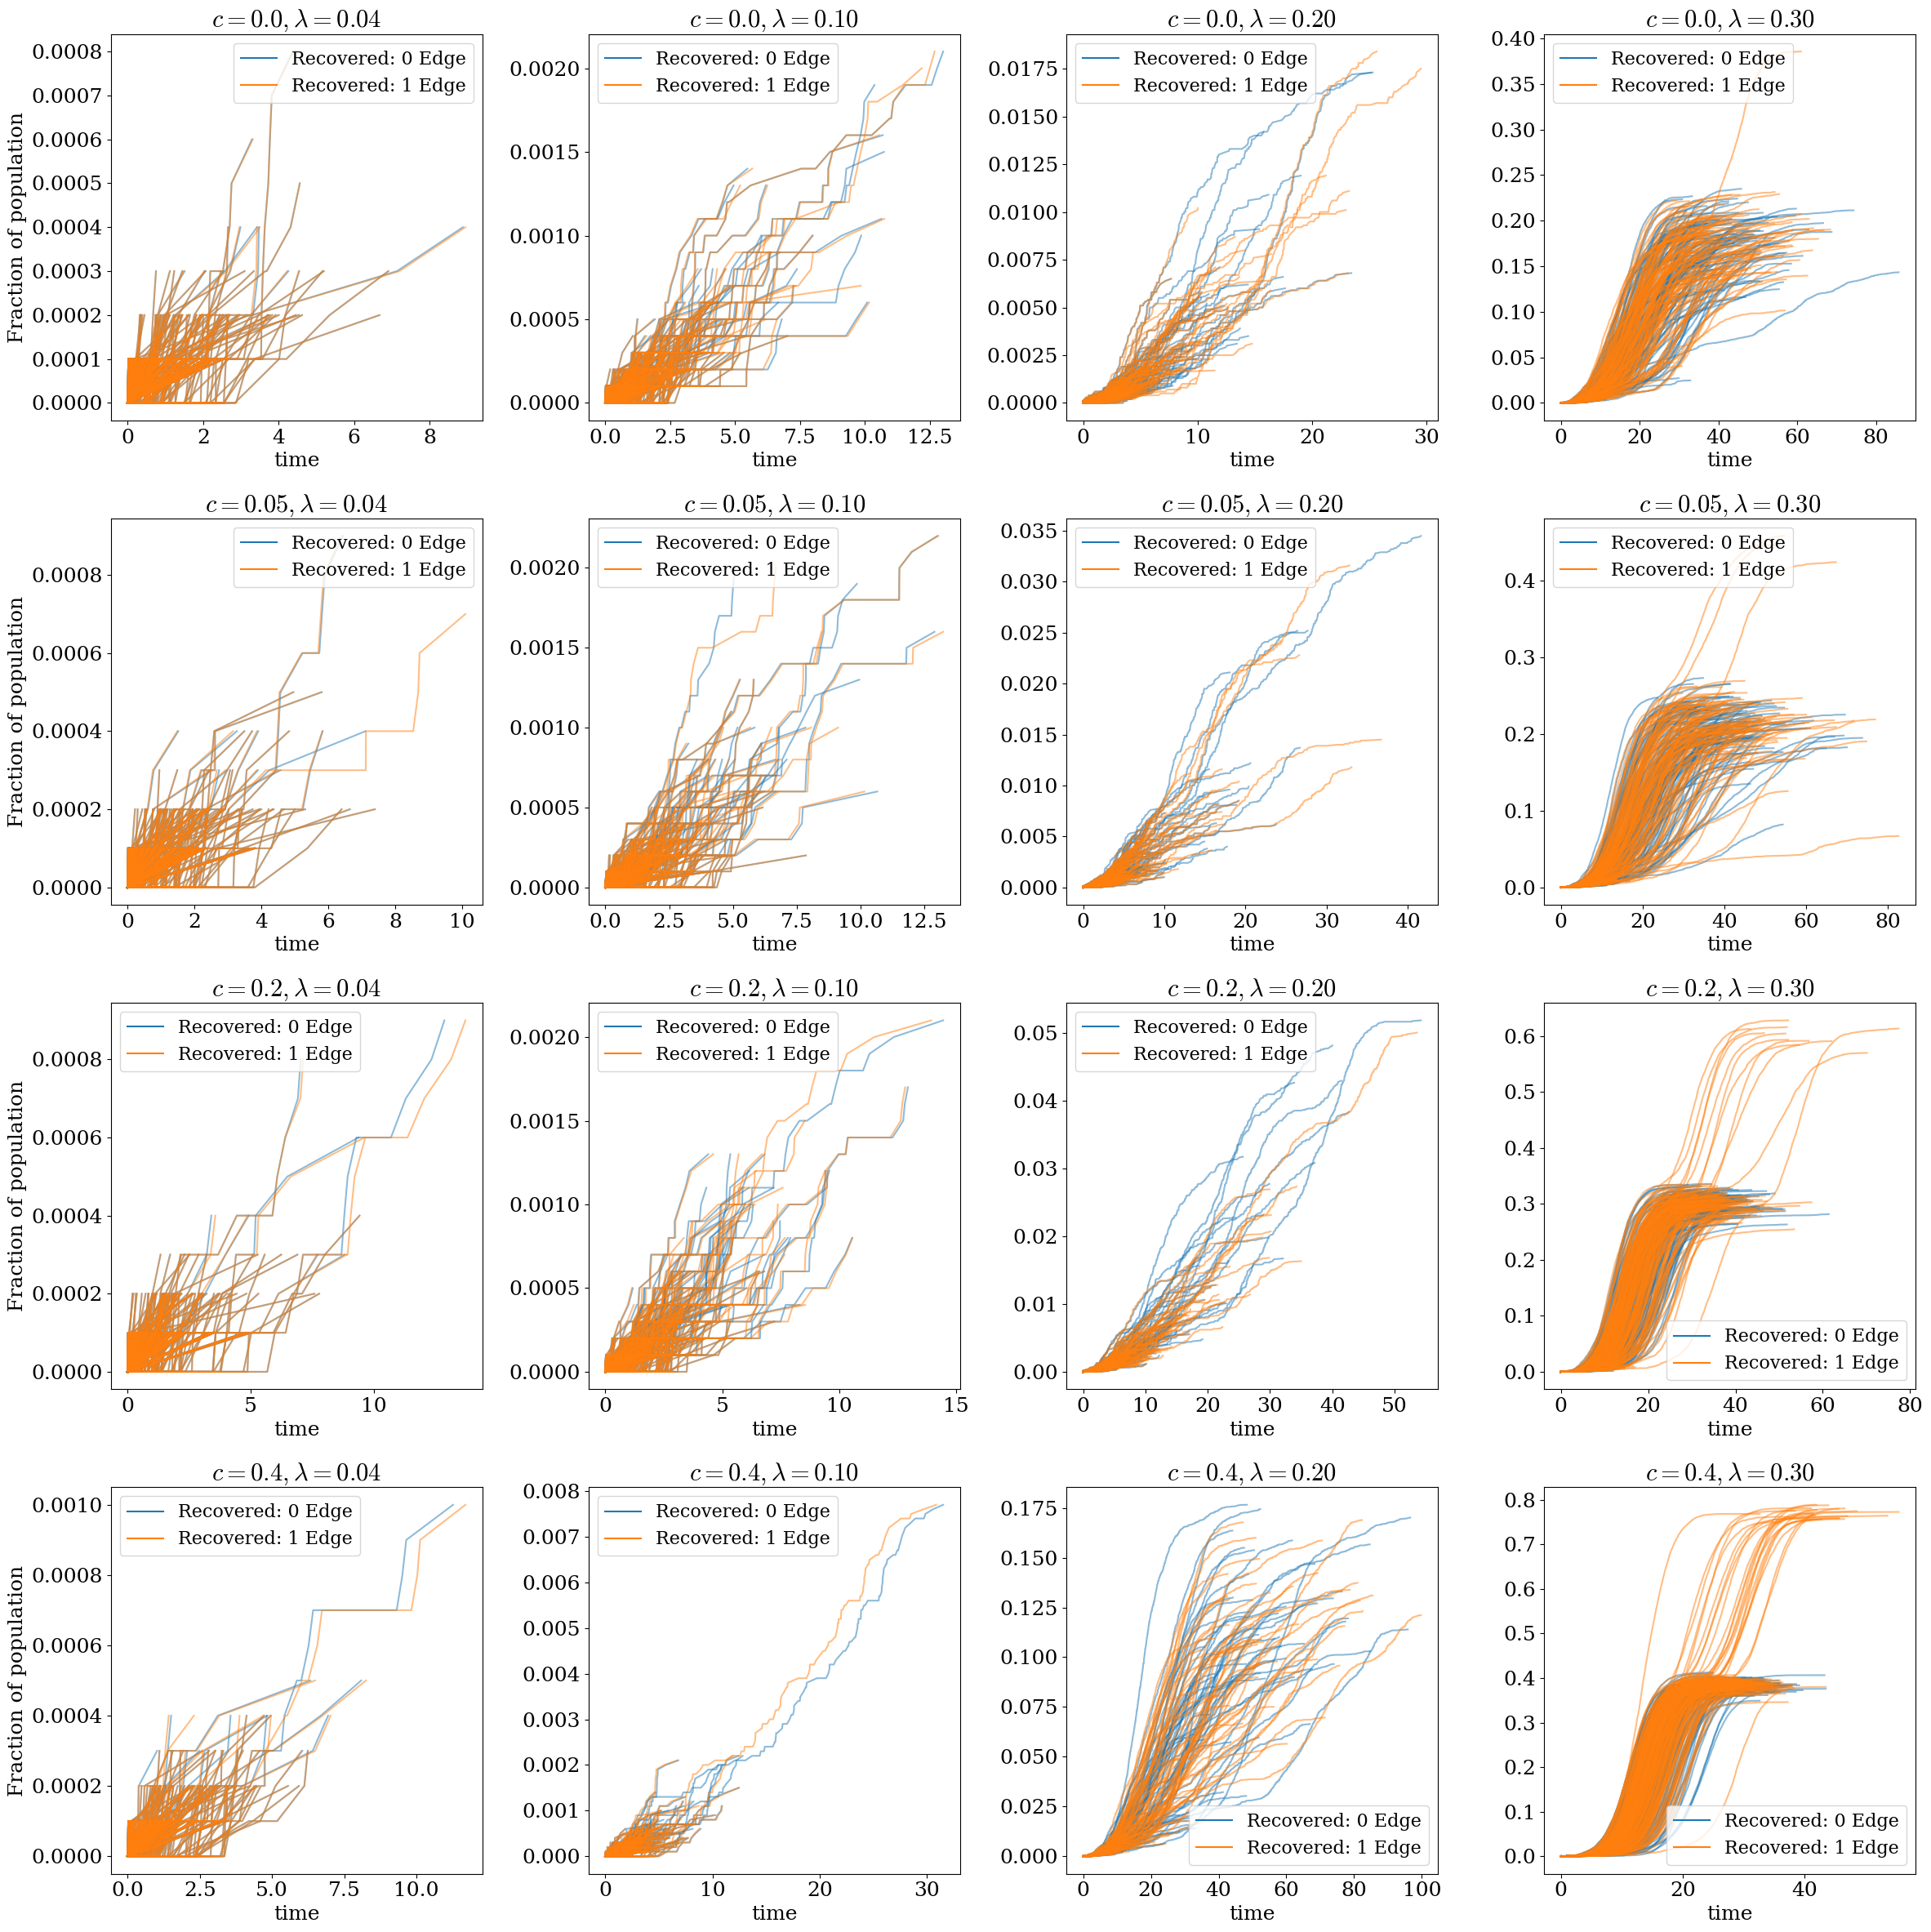

In [6]:
fig, axes_plot = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)))
edge_idx_list = [0, 1]

for c_idx, c in enumerate(c_list):
    for l_idx, lamb_idx in enumerate(lamb_idx_list):
        v_num = 0
        lamb = lamb_values[lamb_idx]
        for e_idx, edge_idx in enumerate(edge_idx_list):
            edge_num = edge_num_list[edge_idx]
            axes_plot[c_idx, l_idx].plot([], [], color=colors[e_idx], label=f"Recovered: {edge_num} Edge")
            for itr_idx in range(total_itr):
                R = recovered_num_all[edge_idx, c_idx, lamb_idx, itr_idx]
                t = times_all[edge_idx, c_idx, lamb_idx, itr_idx]
                axes_plot[c_idx, l_idx].plot(t, R/(2*N), color=colors[e_idx], alpha=0.5)
                axes_plot[c_idx, l_idx].legend()
        axes_plot[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        axes_plot[c_idx, l_idx].set_xlabel("time")
        # axes_plot[c_idx, l_idx].set_yscale("log")
        if l_idx == 0:
            axes_plot[c_idx, l_idx].set_ylabel(r"Fraction of population")

fig.tight_layout()
plt.show()


In [7]:
threshold = 0
time = tmax
time_idx = np.zeros((len(edge_num_list), len(c_list), len(lamb_values), total_itr), dtype=int)

for e_idx in range(len(edge_num_list)):
    print(f"e: {e_idx + 1} / {len(edge_num_list)}")
    for c_idx in range(len(c_list)):
        is_print_c = c_idx % 10 == 0
        if is_print_c:
            print(f" -->c: {c_idx} / {len(c_list)}")
        for l_idx in range(len(lamb_values)):
            is_print_lambda = l_idx % 10 == 0
            if is_print_lambda:
                print(f"   -->l: {l_idx} / {len(lamb_values)}")
            for itr_idx in range(total_itr):
                last_time = times_all[e_idx, c_idx, l_idx, itr_idx][-1]
                if last_time > time:
                    time_idx[e_idx, c_idx, l_idx, itr_idx] = int(np.where(times_all[e_idx, c_idx, l_idx, itr_idx] <= time)[0][-1])
                else:
                    time_idx[e_idx, c_idx, l_idx, itr_idx] = -1


R_at_time = np.zeros((len(edge_num_list), len(c_list), len(lamb_values), total_itr))
valid_R_at_time = np.zeros((len(edge_num_list), len(c_list), len(lamb_values)))
valid_num = np.zeros((len(edge_num_list), len(c_list), len(lamb_values)))
for e_idx in range(len(edge_num_list)):
    for c_idx in range(len(c_list)):
        for lamb_idx in range(len(lamb_values)):
            valid = []
            non_valid = []
            for itr_idx in range(total_itr):
                R_at_time[e_idx, c_idx, lamb_idx, itr_idx] = recovered_num_all[e_idx, c_idx, lamb_idx, itr_idx][time_idx[e_idx, c_idx, lamb_idx, itr_idx]]
                if R_at_time[e_idx, c_idx, lamb_idx, itr_idx] > threshold:
                    valid.append(R_at_time[e_idx, c_idx, lamb_idx, itr_idx])
                    valid_num[e_idx, c_idx, lamb_idx] += 1
                else:
                    non_valid.append(R_at_time[e_idx, c_idx, lamb_idx, itr_idx])
            if len(valid) > 0:
                valid_R_at_time[e_idx, c_idx, lamb_idx] = np.mean(valid)
            else:
                valid_R_at_time[e_idx, c_idx, lamb_idx] = np.mean(non_valid)


e: 1 / 5
 -->c: 0 / 4
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
e: 2 / 5
 -->c: 0 / 4
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
e: 3 / 5
 -->c: 0 / 4
   -->l: 0 / 51
   -->l: 10 / 51
   -->l: 20 / 51
   -->l: 30 / 51
   -->l: 40 / 51
   -->l: 50 / 51
   -->l: 0 / 51
   -->l: 

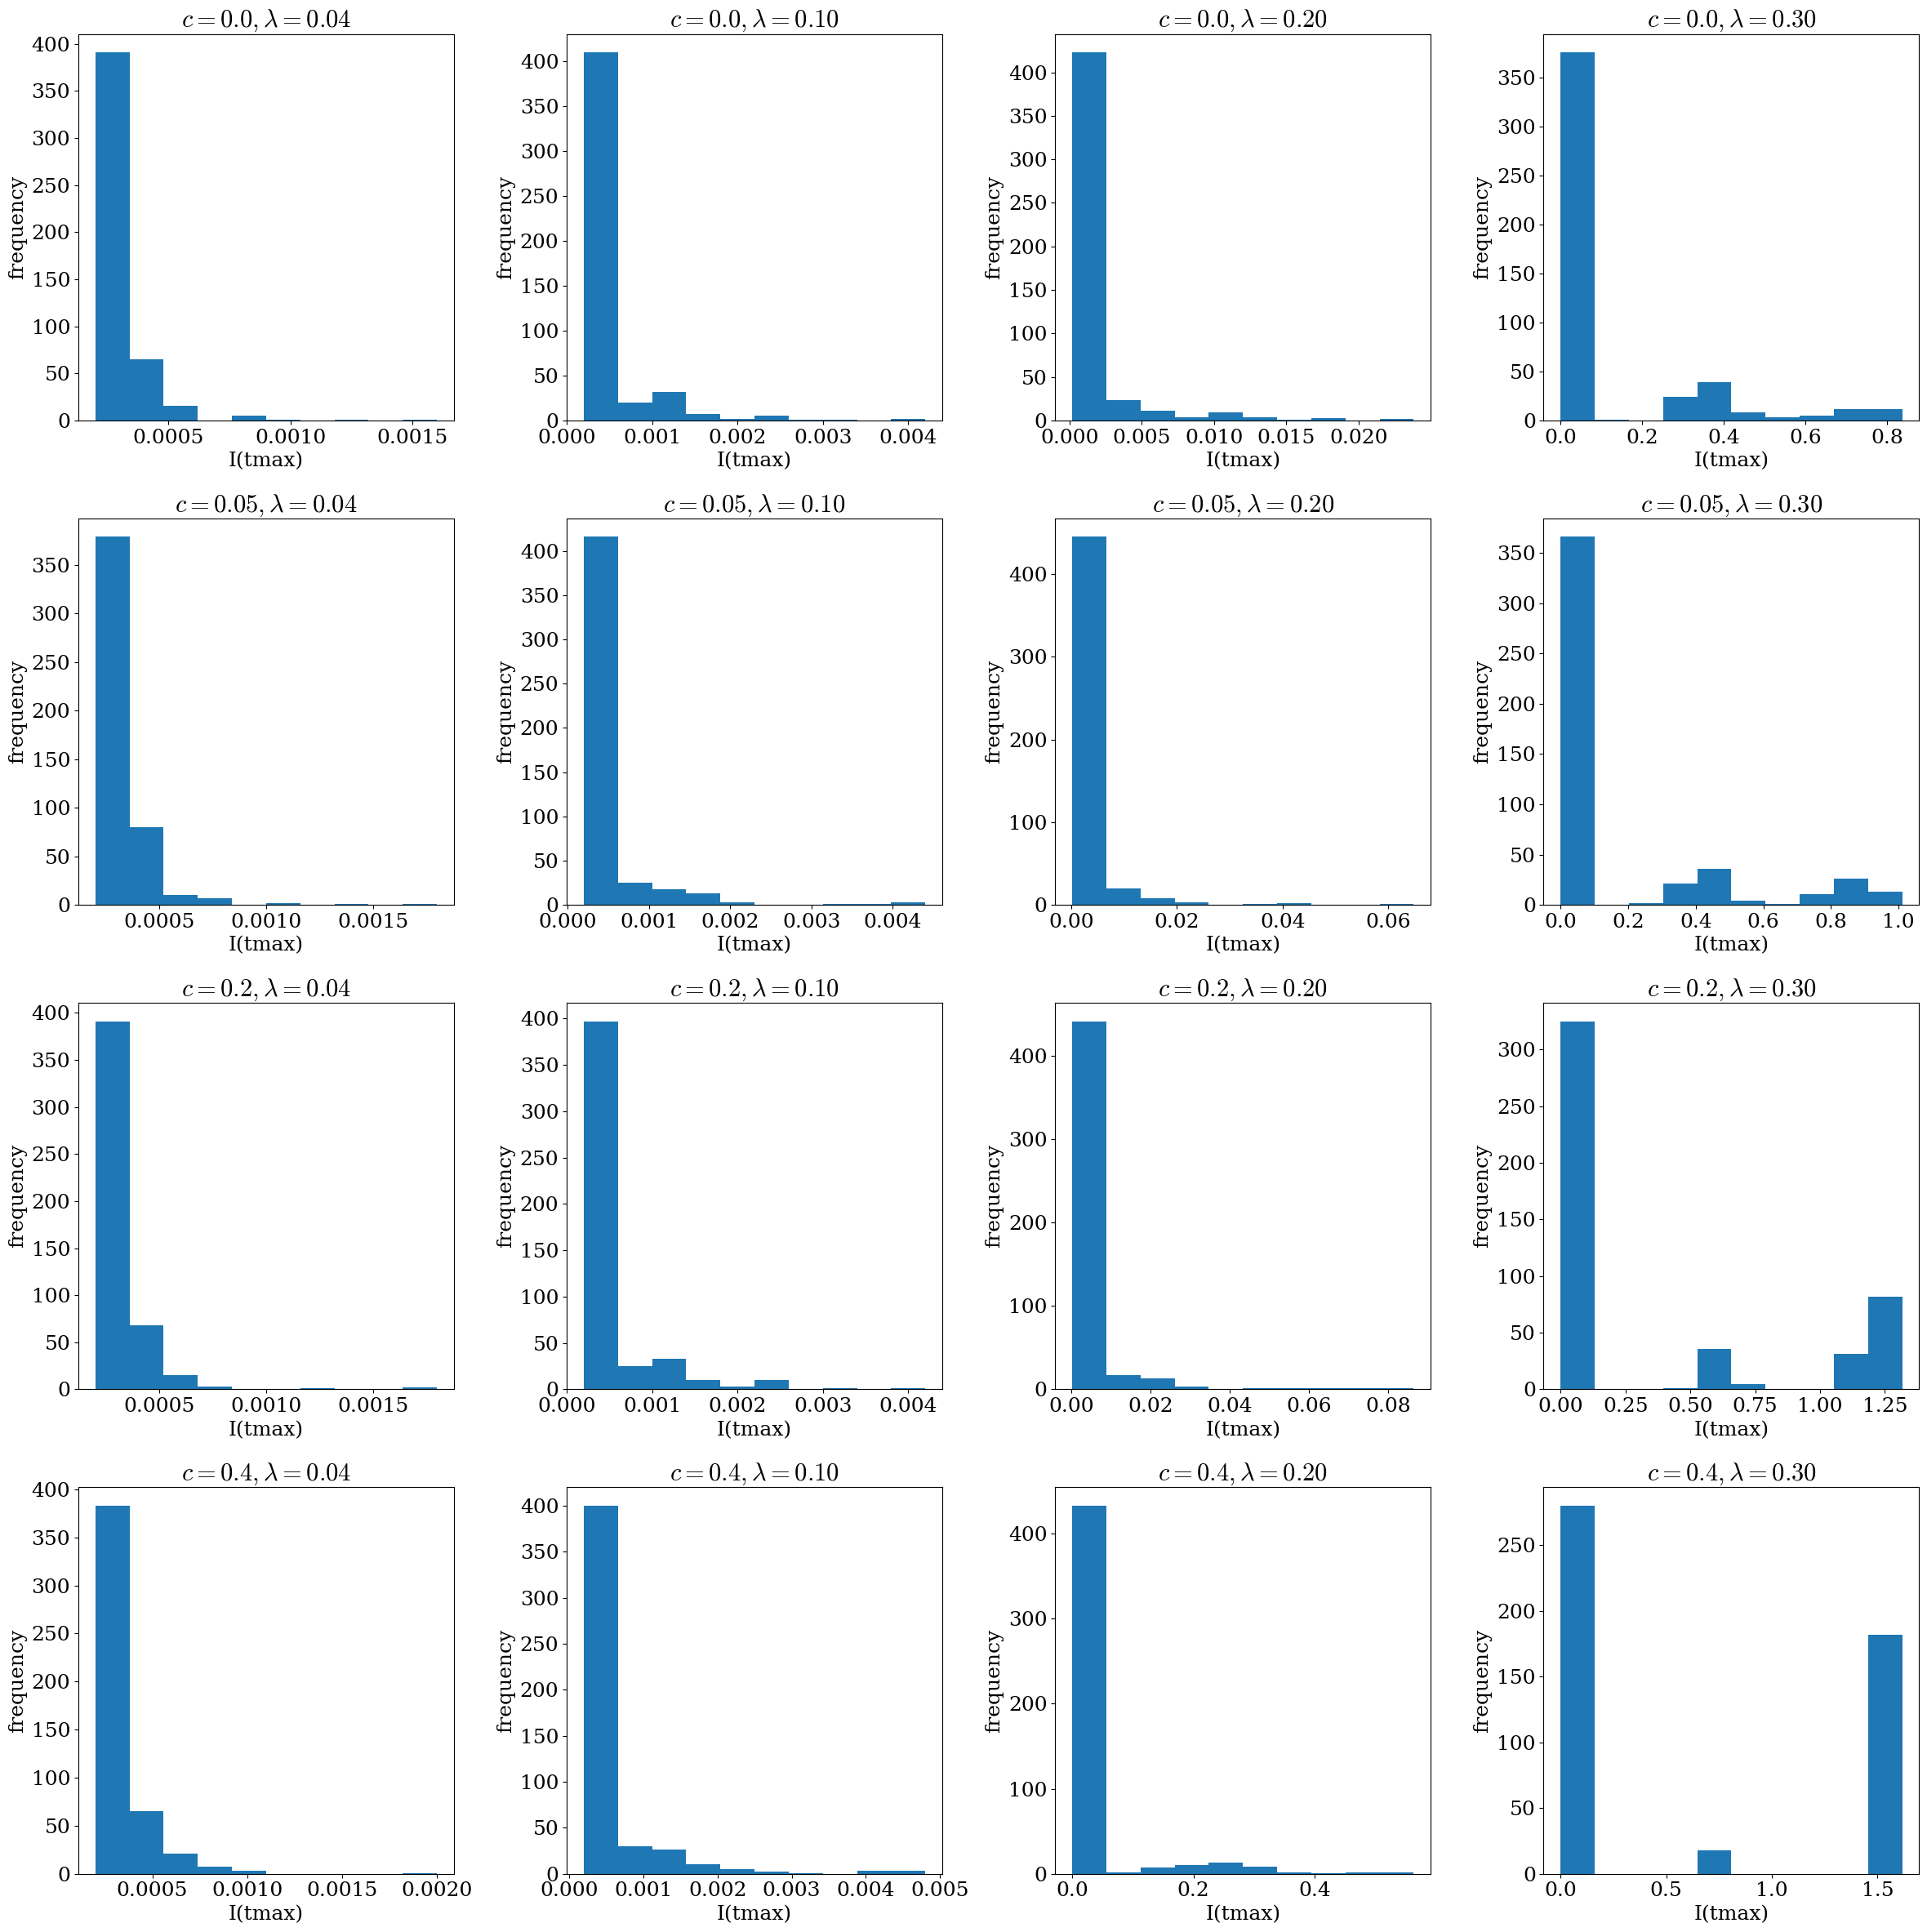

In [8]:
fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)))

for c_idx, c in enumerate(c_list):
    for l_idx, lamb_idx in enumerate(lamb_idx_list):
        lamb = lamb_values[lamb_idx]
        axes[c_idx, l_idx].hist(R_at_time[e_idx, c_idx, lamb_idx, :]/N, bins=10)
        axes[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        axes[c_idx, l_idx].set_xlabel("I(tmax)")
        axes[c_idx, l_idx].set_ylabel("frequency")

fig.tight_layout()

plt.show()

In [9]:
# lamb_values_for_theory = np.linspace(np.min(lamb_values), np.max(lamb_values), 1000)
# theta_all = np.zeros((len(c_list), len(lamb_values_for_theory)))

# for cidx, c in enumerate(c_list):
#     theta_results = []

#     # 各lambdaについてニュートン法でThetaを解く
#     for lamb in lamb_values_for_theory:
#         if network_type == "RR":
#             # 次数のリスト
#             deg_list = [k_ave]
#             pk = np.array([1.0])

#         elif network_type == "ER":
#             # 次数のリスト (ポアソン分布が意味を持つ範囲)
#             # 平均の3倍+10程度あれば十分
#             deg_list = np.arange(0, int(k_ave * 3) + 10)

#             # 次数分布 p(k) を計算 (ポアソン分布)
#             pk = scipy.stats.poisson.pmf(deg_list, k_ave)

#         # elif network_type == "SF":
#         #     deg_list = np.arange(1, 1000)

#         #     C = (2 - kappa) * k_ave
#         #     pk = C * deg_list ** (- kappa)

#         else:
#             raise ValueError(f"Invalid network type: {network_type}")

#         # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
#         # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
#         solution = newton_method(deg_list, pk, lamb, gamma, c=c)
        
#         # 物理的に意味のある解は Theta >= 0
#         if solution < 0:
#             solution = 0
            
#         theta_results.append(solution)
#         # print(f"{lamb:.4f}, {solution:.8f}")

#     theta_all[cidx, :] = np.array(theta_results)

# I_theory = np.zeros((len(c_list), len(lamb_values_for_theory)))
# for cidx, c in enumerate(c_list):
#     for lamb_idx, lamb in enumerate(lamb_values_for_theory):
#         I_theory[cidx, lamb_idx] = theta_to_I(deg_list, pk, lamb, gamma, theta_all[cidx, lamb_idx], c=c)

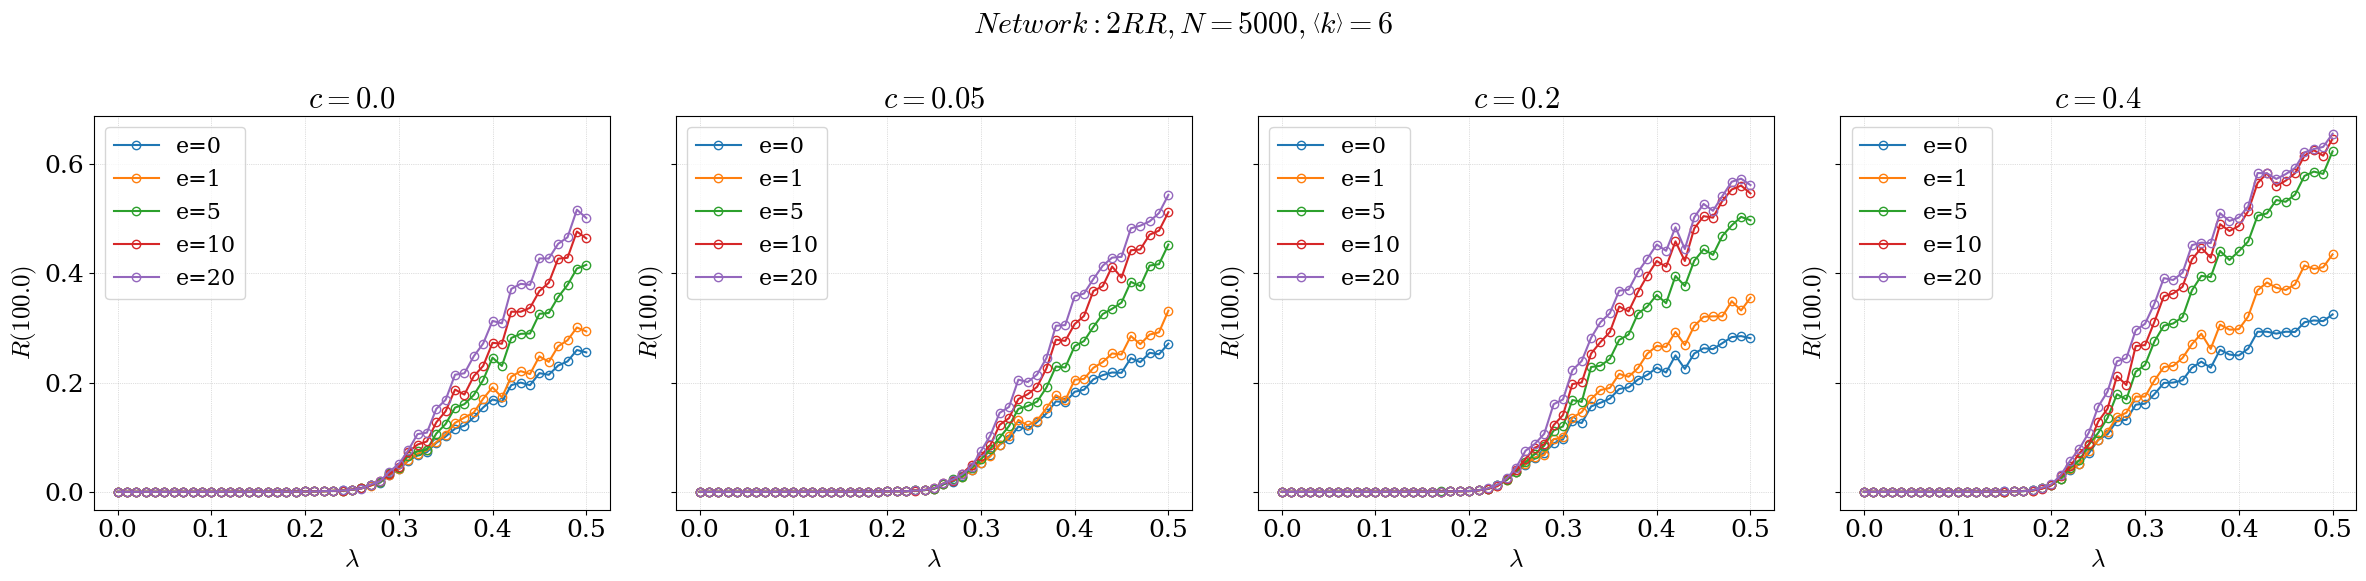

In [10]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6), sharey=True)

for e_idx, e in enumerate(edge_num_list):
    for c_idx, c in enumerate(c_list):
        # axes[c_idx].plot(lamb_values_for_theory, I_theory[c_idx, :], label="Theory", linestyle="--", linewidth=0.5)
        axes[c_idx].plot(lamb_values, valid_R_at_time[e_idx, c_idx, :]/(2*N), color=colors[e_idx], label=f"e={e}", linestyle="-", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])
        axes[c_idx].legend()
        axes[c_idx].grid(True, linestyle=":", alpha=0.5)
        axes[c_idx].set_title(rf"$c={c}$")
        axes[c_idx].set_xlabel(r"$\lambda$")
        axes[c_idx].set_ylabel(rf"$R({time})$")

fig.suptitle(rf"$Network: {network_type}, N={N}, \left<k\right>={k_ave}$")
fig.tight_layout()

plt.show()